In [1]:
import numpy as np
import matplotlib.pyplot as plt

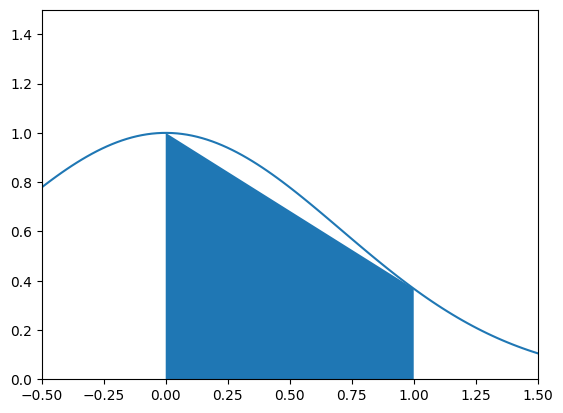

In [2]:
x = np.linspace(-0.5,1.5,100)
y = np.exp(-x**2)
plt.plot(x,y)

x0 = 0; x1 = 1;
y0 = np.exp(-x0**2); y1 = np.exp(-x1**2);
plt.fill_between([x0,x1],[y0,y1])

plt.xlim([-0.5,1.5]); plt.ylim([0,1.5]);
plt.show()

In [3]:
A = 0.5*(y1 + y0)*(x1 - x0)
print("Trapezoid area:", A)

Trapezoid area: 0.6839397205857212


In [4]:
def trapz(f,a,b,N=50):
    '''Approximate the integral of f(x) from a to b by the trapezoid rule.

    The trapezoid rule approximates the integral \int_a^b f(x) dx by the sum:
    (dx/2) \sum_{k=1}^N (f(x_k) + f(x_{k-1}))
    where x_k = a + k*dx and dx = (b - a)/N.

    Parameters
    ----------
    f : function
        Vectorized function of a single variable
    a , b : numbers
        Interval of integration [a,b]
    N : integer
        Number of subintervals of [a,b]

    Returns
    -------
    float
        Approximation of the integral of f(x) from a to b using the
        trapezoid rule with N subintervals of equal length.

    Examples
    --------
    >>> trapz(np.sin,0,np.pi/2,1000)
    0.9999997943832332
    '''
    x = np.linspace(a,b,N+1) # N+1 points make N subintervals
    y = f(x)
    y_right = y[1:] # right endpoints
    y_left = y[:-1] # left endpoints
    dx = (b - a)/N
    T = (dx/2) * np.sum(y_right + y_left)
    return T

In [5]:
trapz(np.sin,0,np.pi/2,1000)

np.float64(0.9999997943832332)

In [6]:
trapz(lambda x : 3*x**2,0,1,10000)

np.float64(1.0000000050000002)

In [7]:
trapz(lambda x : x,0,1,1)

np.float64(0.5)

In [8]:
def trapz2(f,a,b,N=50):
    '''Approximate the integral of f(x) from a to b by the trapezoid rule.

    The trapezoid rule approximates the integral \int_a^b f(x) dx by the sum:
    (dx/2) \sum_{k=1}^N (f(x_k) + f(x_{k-1}))
    where x_k = a + k*dx and dx = (b - a)/N.

    Parameters
    ----------
    f : function
        Vectorized function of a single variable
    a , b : numbers
        Interval of integration [a,b]
    N : integer
        Number of subintervals of [a,b]

    Returns
    -------
    float
        Approximation of the integral of f(x) from a to b using the
        trapezoid rule with N subintervals of equal length.

    Examples
    --------
    >>> trapz(np.sin,0,np.pi/2,1000)
    0.9999997943832332
    '''
    x = np.linspace(a,b,N+1) # N+1 points make N subintervals
    y = f(x)
    dx = (b - a)/N
    T = (dx) * (np.sum(y)-(y[0]+y[-1])/2)
    return T

In [9]:
trapz2(np.sin,0,np.pi/2,1000)

np.float64(0.9999997943832332)

In [10]:
import scipy.integrate as spi

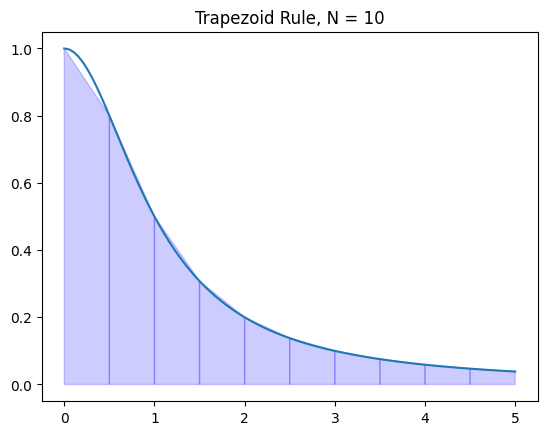

In [11]:
f = lambda x : 1/(1 + x**2)
a = 0; b = 5; N = 10

# x and y values for the trapezoid rule
x = np.linspace(a,b,N+1)
y = f(x)

# X and Y values for plotting y=f(x)
X = np.linspace(a,b,100)
Y = f(X)
plt.plot(X,Y)

for i in range(N):
    xs = [x[i],x[i],x[i+1],x[i+1]]
    ys = [0,f(x[i]),f(x[i+1]),0]
    plt.fill(xs,ys,'b',edgecolor='b',alpha=0.2)

plt.title('Trapezoid Rule, N = {}'.format(N))
plt.show()

In [12]:
T = spi.trapezoid(y,x)
print(T)

1.3731040812301096


In [13]:
T = spi.trapezoid(Y,X)
print(T)

1.3733976225738


In [14]:
I = np.arctan(5)
print(I)

1.373400766945016


In [15]:
print("Trapezoid Rule Error:",np.abs(I - T))

Trapezoid Rule Error: 3.14437121584632e-06


In [16]:
10**4/np.sqrt(6)

np.float64(4082.4829046386303)

In [17]:
approximation = trapz(lambda x : 1/x,1,2,4083)
print(approximation)

0.6931471843089954


In [18]:
N = 4083
x = np.linspace(1,2,N+1)
y = 1/x
approximation = spi.trapezoid(y,x)
print(approximation)

0.6931471843089955


In [19]:
np.abs(approximation - np.log(2)) < 10**(-8)

np.True_

In [20]:
for n in range(1,4083):
    approx = trapz(lambda x : 1/x,1,2,n)
    if np.abs(approx - np.log(2)) < 10e-8:
        print("Accuracy achieved at N =",n)
        break

Accuracy achieved at N = 791


In [21]:
x = 0
2*np.cos(x**2) - 4*x**2*np.sin(x**2)

np.float64(2.0)

In [22]:
x = 1
2*np.cos(x**2) - 4*x**2*np.sin(x**2)

np.float64(-2.2852793274953065)

In [23]:
np.sqrt(10**5 * 2.2852793274953065 / 12)

np.float64(137.9999796949051)

In [24]:
x = np.linspace(0,1,139)
y = np.sin(x**2)
I = spi.trapezoid(y,x)
print(I)

0.31027303032220394


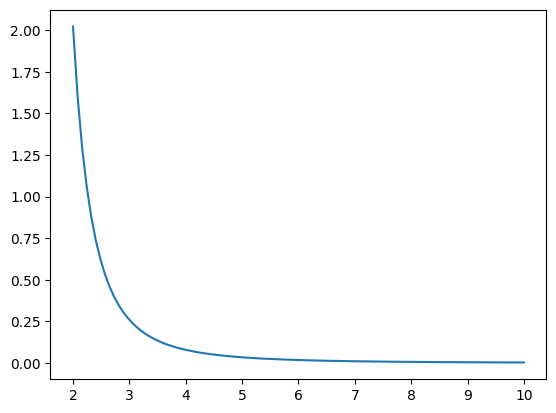

In [25]:
a = 2
b = 10
x = np.linspace(a,b,100)
y = (np.log(x) + 2) / (x**2 * np.log(x)**3)
plt.plot(x,y)
plt.show()

In [26]:
K2 = (np.log(2) + 2)/(4*np.log(2)**3)
print(K2)

2.021732598829855


In [27]:
np.sqrt(8**3 * 10**4 * 2.021732598829855 / 12)

np.float64(928.7657986995814)

In [28]:
N = 929
x = np.linspace(a,b,N+1)
y = 1/np.log(x)
I = spi.trapezoid(y,x)
print(I)

5.120442039184057
